# 01 – Data Audit and Cleaning

Project: Developer Salary Prediction  
Data: [Stack Overflow Developer Survey 2025](https://survey.stackoverflow.co/) (ODbL 1.0)

Goal of the project: help a developer who gets a job offer judge whether the salary is fair, by predicting a typical salary for their profile.

In this notebook I define who belongs in the analysis, check the data quality and clean the data. For every cleaning step I record how many rows it removes.

Output: `data/processed/survey_clean_2025.csv` (7,428 rows), used by the EDA and modelling notebooks.

## 0. Setup

In [1]:
import pandas as pd

# Show long text (e.g. survey questions) in full instead of cutting it off
pd.set_option("display.max_colwidth", None)

## 1. Load the data

The raw files are in `data/raw/` and are not on GitHub (the results file is 135 MB):
- `survey_results_2025.csv`: the answers, one row per respondent
- `survey_schema_2025.csv`: column names and question texts
- `survey_questionnaire_2025.pdf`: the questionnaire with all answer options

In [2]:
# Paths are relative to the notebooks/ folder: "../" goes up to the repository root
df = pd.read_csv("../data/raw/survey_results_2025.csv", low_memory=False)
schema = pd.read_csv("../data/raw/survey_schema_2025.csv")

Without `low_memory=False`, pandas showed a `DtypeWarning` for 11 columns with mixed types. They are free-text "Other" answers, which I won't use.

In [3]:
# Column positions reported in the DtypeWarning
mixed_type_positions = [56, 74, 92, 97, 98, 105, 109, 110, 132, 162, 165]

df.columns[mixed_type_positions].tolist()

['JobSatPoints_15_TEXT',
 'DatabaseHaveEntry',
 'DevEnvHaveEntry',
 'SOTagsHaveEntry',
 'SOTagsWant Entry',
 'OfficeStackWantEntry',
 'CommPlatformHaveEntr',
 'CommPlatformWantEntr',
 'SO_Actions_15_TEXT',
 'AIAgentOrchestration',
 'AIAgentObsWrite']

## 2. First look

One row = one respondent.

In [4]:
df.head()

,ResponseId,MainBranch,Age,EdLevel,Employment,EmploymentAddl,WorkExp,LearnCodeChoose,LearnCode,LearnCodeAI,...,AIAgentOrchestration,AIAgentOrchWrite,AIAgentObserveSecure,AIAgentObsWrite,AIAgentExternal,AIAgentExtWrite,AIHuman,AIOpen,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,25-34 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Employed,"Caring for dependents (children, elderly, etc.)",8.0,"Yes, I am not new to coding but am learning new coding techniques or programming language","Online Courses or Certification (includes all media types);Other online resources (e.g. standard search, forum, online community)","Yes, I learned how to use AI-enabled tools for my personal curiosity and/or hobbies",...,Vertex AI,NaN,NaN,NaN,ChatGPT,NaN,When I don’t trust AI’s answers,"Troubleshooting, profiling, debugging",61256.0,10.0
1,2,I am a developer by profession,25-34 years old,"Associate degree (A.A., A.S., etc.)",Employed,NaN,2.0,"Yes, I am not new to coding but am learning new coding techniques or programming language","Online Courses or Certification (includes all media types);Other online resources (e.g. standard search, forum, online community);Books / Physical media;Videos (not associated with specific online course or certification);Stack Overflow or Stack Exchange","Yes, I learned how to use AI-enabled tools for my personal curiosity and/or hobbies",...,NaN,NaN,NaN,NaN,NaN,NaN,When I don’t trust AI’s answers;When I want to fully understand something;When I want to learn best practices;When I want to compare different solutions;When I have ethical or security concerns about code,All skills. AI is a flop.,104413.0,9.0
2,3,I am a developer by profession,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Independent contractor, freelancer, or self-employed",None of the above,10.0,"Yes, I am not new to coding but am learning new coding techniques or programming language",Online Courses or Certification (includes all media types);Videos (not associated with specific online course or certification);Technical documentation (is generated for/by the tool or system),"Yes, I learned how to use AI-enabled tools for my personal curiosity and/or hobbies",...,NaN,NaN,NaN,NaN,ChatGPT;Claude Code;GitHub Copilot;Google Gemini,NaN,When I don’t trust AI’s answers;When I want to fully understand something;When I want to learn best practices;When I have ethical or security concerns about code;When I’m stuck and can’t explain the problem,"Understand how things actually work, problem solving, and algorithms",53061.0,8.0
3,4,I am a developer by profession,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Employed,None of the above,4.0,"Yes, I am not new to coding but am learning new coding techniques or programming language","Other online resources (e.g. standard search, forum, online community);Videos (not associated with specific online course or certification);Stack Overflow or Stack Exchange;Technical documentation (is generated for/by the tool or system);AI CodeGen tools or AI-enabled apps","Yes, I learned how to use AI-enabled tools for my personal curiosity and/or hobbies",...,NaN,NaN,NaN,NaN,ChatGPT;Claude Code,NaN,When I don’t trust AI’s answers;When I want to fully understand something;When I have ethical or security concerns about code;When I’m stuck and can’t explain the problem,NaN,36197.0,6.0
4,5,I am a developer by profession,35-44 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)","Independent contractor, freelancer, or self-employed","Caring for dependents (children, elderly, etc.)",21.0,"No, I am not new to coding and did not learn new coding techniques or programming languages",NaN,"Yes, I learned how to use AI-enabled tools for my personal curiosity and/or hobbies",...,NaN,NaN,NaN,NaN,NaN,NaN,When I don’t trust AI’s answers,"critical thinking, the skill to define the task correctly",60000.0,7.0


In [5]:
# Number of rows (respondents) and columns (survey fields)
print(df.shape)

# How many columns of each data type
df.dtypes.value_counts()

(49191, 172)


object     119
float64     52
int64        1
Name: count, dtype: int64

In [6]:
# ResponseId should be unique: one ID per respondent
df["ResponseId"].duplicated().sum()

np.int64(0)

## 3. Column documentation

The schema links each column to its question. Some questions are split into several columns, e.g. `Language` becomes `LanguageHaveWorkedWith`, `LanguageWantToWorkWith` and `LanguageAdmired`. `ConvertedCompYearly` is not a survey question: Stack Overflow calculated it from `CompTotal` and `Currency`.

In [7]:
# Look up one column by its exact name
schema[schema["qname"] == "WorkExp"][["qname", "question", "type"]]

,qname,question,type
54,WorkExp,"How many years of professional work experience do you have? Please round to the nearest whole number, excluding any decimal points. If your answer is '0', please leave blank.",TE


In [8]:
# Search for all columns whose name contains a keyword
schema[schema["qname"].str.contains("Comp")][["qname", "question", "type"]]

,qname,question,type
74,CompTotal,"What is your current total <b>annual</b> compensation (salary, bonuses, and perks, before taxes and deductions) in terms of your day-to-day currency? Please enter a whole number in the box below, without any punctuation. If you are paid hourly, please estimate an equivalent yearly salary. If you prefer not to answer, please leave the box empty.",TE
119,AIComplex,How well do the AI tools you use in your development workflow handle complex tasks?,MC


## 4. Data dictionary

The columns I use, based on the schema and the questionnaire.

| Column | Meaning | Type | Role | Notes |
|---|---|---|---|---|
| `ConvertedCompYearly` | Total annual compensation (salary, bonuses, perks, before tax), converted to USD | Numeric | Target | Calculated by Stack Overflow from `CompTotal` and `Currency`. Answering was optional |
| `CompTotal` | Total annual compensation in the respondent's own currency | Numeric | Excluded (leakage) | The salary itself, in local currency |
| `Currency` | Currency used day-to-day | Categorical (single choice) | Excluded (leakage) | Used to calculate the target |
| `MainBranch` | Whether the respondent is a professional developer, learner, hobbyist, etc. | Categorical (single choice) | Scope filter | Kept: "I am a developer by profession" |
| `Employment` | Current employment status | Categorical (single choice) | Scope filter | Kept: "Employed". The 2025 survey has no full-time/part-time split |
| `Country` | Country of residence | Categorical (single choice) | Scope filter / candidate feature | Kept: EU-27 plus Iceland, Norway, Switzerland and the UK. The 8 smallest countries are grouped by region (section 13.2) |
| `WorkExp` | Years of professional work experience | Numeric | Candidate feature | The survey says to leave it blank if the answer is 0, so blanks are set to 0 (section 12) |
| `YearsCode` | Total years of coding, including education | Numeric | Candidate feature | Usually higher than `WorkExp` because it includes study years |
| `DevType` | Current job role (e.g. back-end, data scientist, engineering manager) | Categorical (single choice) | Candidate feature | Grouped from 30 roles into 12 job families (section 13.1) |
| `EdLevel` | Highest completed level of formal education | Categorical (single choice) | Candidate feature | "Other" set to missing, ordered (section 13.3) |
| `OrgSize` | Number of employees at the employer | Categorical (single choice) | Candidate feature | "I don't know" set to missing, ordered (section 13.3) |
| `RemoteWork` | Current work situation | Categorical (single choice) | Candidate feature | Labels shortened (section 13.4) |
| `Industry` | Industry of the employer | Categorical (single choice) | Candidate feature | "Other" kept as a category |
| `LanguageHaveWorkedWith` | Programming languages used in the past year | Multi-select text | Candidate feature | Split into one 0/1 column per language (`lang_...`, section 14) |
| `ICorPM` | Individual contributor or people manager | Categorical (two values) | Candidate feature | Probably a strong salary driver |
| `Age` | Age group (e.g. "25-34 years old") | Ordered categorical | Candidate feature (to verify) | Age ranges, not exact age. May overlap with `WorkExp`, check in EDA |
| `n_languages` | Number of languages used | Numeric | Candidate feature | Created in section 14 |
| `languages_missing` | 1 if the respondent has no language data | 0/1 | Candidate feature | Created in section 14 |

## 5. Target variable

The salary question was optional, and rows without a salary can't be used for training. So first I check how many are missing and what the distribution looks like.

In [9]:
target = "ConvertedCompYearly"

# Count and share of missing target values
print("Missing:", df[target].isnull().sum())
print("Missing %:", round(df[target].isnull().mean() * 100, 1))

# Summary statistics of the target
df[target].describe().round(0)

Missing: 25244
Missing %: 51.3


count       23947.0
mean       101762.0
std        461757.0
min             1.0
25%         38171.0
50%         75320.0
75%        120596.0
max      50000000.0
Name: ConvertedCompYearly, dtype: float64

Notes:
- 51.3% (25,244) have no salary. That leaves 23,947 rows, which is enough. I drop the missing ones instead of filling them in, because a filled-in target would be made up.
- The middle 50% earn roughly 38,000 to 121,000 USD (median 75,320).
- A minimum of 1 USD and a maximum of 50 million USD are clearly wrong. I deal with this in section 11.
- The mean (101,762) is much higher than the median, so salaries are right-skewed. I'll try a log-transformed target later.

## 6. Scope

The model should learn from people who are similar to my target user. Three columns decide this: `MainBranch` (professional developer or not), `Employment` and `Country`. I only count respondents who gave a salary.

In [10]:
# Keep only respondents who reported a salary
has_salary = df[df[target].notnull()]

print(has_salary["MainBranch"].value_counts(), "\n")
print(has_salary["Employment"].value_counts(), "\n")

# Top 20 countries by number of respondents with a salary
has_salary["Country"].value_counts().head(20)

MainBranch
I am a developer by profession                                                                20195
I am not primarily a developer, but I write code sometimes as part of my work/studies          2187
I used to be a developer by profession, but no longer am                                        498
I work with developers or my work supports developers but am not a developer by profession      390
I am learning to code                                                                           363
I code primarily as a hobby                                                                     314
Name: count, dtype: int64 

Employment
Employed                                                19500
Independent contractor, freelancer, or self-employed     3050
Student                                                   703
Not employed                                              504
Retired                                                   133
I prefer not to say                     

Country
United States of America                                5243
Germany                                                 2141
United Kingdom of Great Britain and Northern Ireland    1486
India                                                   1096
France                                                  1027
Canada                                                   915
Ukraine                                                  709
Brazil                                                   639
Netherlands                                              619
Poland                                                   589
Italy                                                    581
Australia                                                569
Spain                                                    560
Sweden                                                   471
Switzerland                                              418
Czech Republic                                           361
Austria         

Notes:
- 84% (20,195) are professional developers. The rest (hobbyists, students, people who code now and then) are not my target user.
- 19,500 are employed and 3,050 are freelancers. Freelance income isn't comparable to a salary offer.
- The US is by far the biggest country (5,243). The Netherlands has 619.
- Small issues: some "Not employed" (504) and "Student" (703) respondents still gave a salary, and some countries appear under two names (e.g. "Moldova" and "Republic of Moldova"). Both fall outside my scope anyway.

Scope decision: employed professional developers in Europe (EU-27 plus Iceland, Norway, Switzerland and the UK, 31 countries).
- World: dominated by the US, and many countries with very few rows.
- Netherlands only: about 450 rows, too few for a reliable test set.
- Europe: about 7,700 rows and a realistic job market for someone in the Netherlands. Differences between countries are handled by using `Country` as a feature.

## 7. Missing values per column

Many columns are almost empty. Being empty and being irrelevant are two different reasons to drop a column, so here I check how empty the candidate features really are.

In [11]:
# Share of missing values per column, in percent, highest first
missing_pct = df.isnull().mean().mul(100).round(1).sort_values(ascending=False)

missing_pct.head(30)

AIAgentObsWrite                   99.5
SOTagsHaveEntry                   99.1
SOTagsWant Entry                  99.1
AIModelsWantEntry                 99.0
AIAgentOrchWrite                  99.0
JobSatPoints_15_TEXT              98.7
AIAgentKnowWrite                  98.4
AIModelsHaveEntry                 98.4
AIAgentExtWrite                   98.3
SO_Actions_15_TEXT                98.3
CommPlatformWantEntr              97.6
CommPlatformHaveEntr              97.0
DatabaseWantEntry                 96.9
TechOppose_15_TEXT                96.7
OfficeStackWantEntry              96.7
TechEndorse_13_TEXT               95.9
DevEnvWantEntry                   95.7
DatabaseHaveEntry                 95.6
OfficeStackHaveEntry              94.7
WebframeWantEntry                 94.7
AIAgentObserveSecure              94.5
DevEnvHaveEntry                   94.4
PlatformWantEntry                 93.7
LanguagesWantEntry                93.6
WebframeHaveEntry                 93.3
AIAgentKnowledge         

In [12]:
# How many columns pass a given emptiness threshold
print("Columns more than 50% empty:", (missing_pct > 50).sum())
print("Columns more than 90% empty:", (missing_pct > 90).sum())

Columns more than 50% empty: 71
Columns more than 90% empty: 30


In [13]:
candidate_features = ["WorkExp", "YearsCode", "Country", "DevType", "EdLevel",
                      "OrgSize", "RemoteWork", "Industry", "LanguageHaveWorkedWith",
                      "ICorPM", "Age"]

# Missing % of candidate features, only among respondents with a salary
has_salary[candidate_features].isnull().mean().mul(100).round(1).sort_values(ascending=False)

ICorPM                    12.9
RemoteWork                11.9
OrgSize                   11.5
LanguageHaveWorkedWith     7.6
Industry                   3.8
WorkExp                    2.0
YearsCode                  0.5
EdLevel                    0.1
Country                    0.0
DevType                    0.0
Age                        0.0
dtype: float64

Notes:
- 71 columns are more than half empty and 30 are more than 90% empty. Most are free-text fields (`Entry`, `Write`, `_TEXT`) or questions that were only shown to some people.
- The candidate features look fine: the emptiest ones (`ICorPM`, `OrgSize`, `RemoteWork`) are 12 to 13% empty, `WorkExp` about 2%. I check again after filtering.

## 8. Apply the scope filters

I apply the filters one by one to see how many rows each one removes. Before filtering on country I check that all 31 names are spelled exactly as in the data, otherwise a country would silently disappear.

In [14]:
# Europe = EU-27 plus Iceland, Norway, Switzerland and the United Kingdom (31 countries)
eu_27 = ["Austria", "Belgium", "Bulgaria", "Croatia", "Cyprus", "Czech Republic", "Denmark",
         "Estonia", "Finland", "France", "Germany", "Greece", "Hungary", "Ireland", "Italy",
         "Latvia", "Lithuania", "Luxembourg", "Malta", "Netherlands", "Poland", "Portugal",
         "Romania", "Slovakia", "Slovenia", "Spain", "Sweden"]
other_europe = ["Iceland", "Norway", "Switzerland",
                "United Kingdom of Great Britain and Northern Ireland"]
europe = eu_27 + other_europe

print("Countries in the list:", len(europe))

# Names in the list that don't appear in the data (should be empty)
[country for country in europe if country not in df["Country"].unique()]

Countries in the list: 31


[]

In [15]:
# Step 1: keep rows with a salary (the target cannot be imputed)
step1 = df[df[target].notnull()]

# Step 2: keep professional developers only
step2 = step1[step1["MainBranch"] == "I am a developer by profession"]

# Step 3: keep employed respondents only (no freelancers, students, unemployed, retired)
step3 = step2[step2["Employment"] == "Employed"]

# Step 4: keep respondents living in Europe (31 countries)
df_scope = step3[step3["Country"].isin(europe)].copy()

# Funnel table: rows remaining after each filter
funnel = pd.DataFrame({
    "step": ["Raw data", "Has salary", "Professional developer", "Employed", "Lives in Europe"],
    "rows": [len(df), len(step1), len(step2), len(step3), len(df_scope)]
})
funnel["share_of_raw_%"] = (funnel["rows"] / len(df) * 100).round(1)

# Rows removed by each step and loss compared with the previous step
funnel["removed"] = funnel["rows"].shift(1) - funnel["rows"]
funnel["loss_vs_previous_%"] = (funnel["removed"] / funnel["rows"].shift(1) * 100).round(1)
funnel

,step,rows,share_of_raw_%,removed,loss_vs_previous_%
0,Raw data,49191,100.0,NaN,NaN
1,Has salary,23947,48.7,25244.0,51.3
2,Professional developer,20195,41.1,3752.0,15.7
3,Employed,16891,34.3,3304.0,16.4
4,Lives in Europe,7709,15.7,9182.0,54.4


In [16]:
# Respondents per country in the final scope
print("Countries:", df_scope["Country"].nunique())
print(df_scope["Country"].value_counts().to_string())

Countries: 31
Country
Germany                                                 1540
United Kingdom of Great Britain and Northern Ireland    1118
France                                                   704
Netherlands                                              446
Spain                                                    396
Italy                                                    394
Sweden                                                   364
Poland                                                   349
Switzerland                                              306
Austria                                                  205
Czech Republic                                           197
Denmark                                                  174
Portugal                                                 163
Norway                                                   155
Finland                                                  142
Belgium                                                  140
Ro

In [17]:
# Missing % of candidate features within the final scope
df_scope[candidate_features].isnull().mean().mul(100).round(1).sort_values(ascending=False)

LanguageHaveWorkedWith    5.9
ICorPM                    1.4
WorkExp                   0.6
RemoteWork                0.3
YearsCode                 0.2
EdLevel                   0.1
OrgSize                   0.1
Industry                  0.1
Country                   0.0
DevType                   0.0
Age                       0.0
dtype: float64

Notes:
- All country names match.
- 7,709 rows remain (15.7% of the raw data). Most rows are lost because of missing salaries and the Europe filter. The other filters remove valid data on purpose, because those people aren't my target user.
- This means the model only applies to employed professional developers in Europe. I'll mention this in the README.
- Germany and the UK together make up 34.5% of the data. The Netherlands is 4th with 446 rows.
- 8 countries have fewer than 50 rows (Iceland only 6). They are grouped by region in section 13.2.
- After filtering, all candidate features are less than 6% empty. `ICorPM`, `RemoteWork` and `OrgSize` went from about 12% to under 1.5%, so most of those gaps came from freelancers and students.

## 9. Data quality audit

From here on I work with the filtered data. First I collect all quality issues, then I fix them in sections 10 to 12.

### 9.1 Keep only the needed columns

I keep `ResponseId`, the target and the candidate features. `CompTotal` and `Currency` are dropped because of leakage, and `MainBranch` and `Employment` because they only have one value left. Cleaning continues on `df_clean`.

In [18]:
# Columns needed for the analysis: ID, target and candidate features
columns_to_keep = ["ResponseId", target] + candidate_features

# All further cleaning happens on df_clean
df_clean = df_scope[columns_to_keep].copy()

print(df_clean.shape)

(7709, 13)


### 9.2 Audit table

In [19]:
audit = pd.DataFrame({
    "dtype": df_clean.dtypes.astype(str),
    "missing_%": df_clean.isnull().mean().mul(100).round(1),
    "unique_values": df_clean.nunique(),
    "example_values": [df_clean[col].dropna().unique()[:3].tolist() for col in df_clean.columns]
})

audit

,dtype,missing_%,unique_values,example_values
ResponseId,int64,0.0,7709,"[2, 28, 36]"
ConvertedCompYearly,float64,0.0,1843,"[104413.0, 209643.0, 95132.0]"
WorkExp,float64,0.6,49,"[2.0, 24.0, 10.0]"
YearsCode,float64,0.2,54,"[10.0, 36.0, 25.0]"
Country,object,0.0,31,"[Netherlands, Sweden, Germany]"
DevType,object,0.0,31,"[Developer, back-end, Developer, full-stack, Developer, game or graphics]"
EdLevel,object,0.1,8,"[Associate degree (A.A., A.S., etc.), Bachelor’s degree (B.A., B.S., B.Eng., etc.), Master’s degree (M.A., M.S., M.Eng., MBA, etc.)]"
OrgSize,object,0.1,9,"[500 to 999 employees, 1,000 to 4,999 employees, Less than 20 employees]"
RemoteWork,object,0.3,5,"[Hybrid (some in-person, leans heavy to flexibility), Hybrid (some remote, leans heavy to in-person), Your choice (very flexible, you can come in when you want or just as needed)]"
Industry,object,0.1,15,"[Retail and Consumer Services, Banking/Financial Services, Higher Education]"


### 9.3 Duplicates

Besides repeated IDs, I check for rows with different IDs but identical answers, which could mean someone answered twice.

In [20]:
# 1. The same ID twice (technical error)
print("Duplicate ResponseId:", df_clean["ResponseId"].duplicated().sum())

# 2. Different IDs, but identical answers in all other columns
print("Duplicate answers (excluding ResponseId):",
      df_clean.drop(columns="ResponseId").duplicated().sum())

Duplicate ResponseId: 0
Duplicate answers (excluding ResponseId): 3


In [21]:
# All rows that belong to a duplicate pair (keep=False marks every copy)
answer_cols = df_clean.columns.drop("ResponseId")
df_clean[df_clean.duplicated(subset=answer_cols, keep=False)].sort_values(target)

,ResponseId,ConvertedCompYearly,WorkExp,YearsCode,Country,DevType,EdLevel,OrgSize,RemoteWork,Industry,LanguageHaveWorkedWith,ICorPM,Age
33769,33770,28083.0,9.0,8.0,Czech Republic,"Developer, back-end","Master’s degree (M.A., M.S., M.Eng., MBA, etc.)","1,000 to 4,999 employees","Hybrid (some remote, leans heavy to in-person)",Higher Education,Java;SQL,Individual contributor,25-34 years old
37400,37401,28083.0,9.0,8.0,Czech Republic,"Developer, back-end","Master’s degree (M.A., M.S., M.Eng., MBA, etc.)","1,000 to 4,999 employees","Hybrid (some remote, leans heavy to in-person)",Higher Education,Java;SQL,Individual contributor,25-34 years old
45690,45691,38285.0,27.0,30.0,Portugal,"Developer, embedded applications or devices","Master’s degree (M.A., M.S., M.Eng., MBA, etc.)","10,000 or more employees","Hybrid (some remote, leans heavy to in-person)",Other:,Bash/Shell (all shells);C;C++;MicroPython;Python,Individual contributor,45-54 years old
45712,45713,38285.0,27.0,30.0,Portugal,"Developer, embedded applications or devices","Master’s degree (M.A., M.S., M.Eng., MBA, etc.)","10,000 or more employees","Hybrid (some remote, leans heavy to in-person)",Other:,Bash/Shell (all shells);C;C++;MicroPython;Python,Individual contributor,45-54 years old
13288,13289,93972.0,16.0,33.0,Germany,"Developer, full-stack","Master’s degree (M.A., M.S., M.Eng., MBA, etc.)","1,000 to 4,999 employees","Hybrid (some in-person, leans heavy to flexibility)",Insurance,C#;HTML/CSS;JavaScript;PowerShell;SQL;TypeScript,Individual contributor,35-44 years old
43909,43910,93972.0,16.0,33.0,Germany,"Developer, full-stack","Master’s degree (M.A., M.S., M.Eng., MBA, etc.)","1,000 to 4,999 employees","Hybrid (some in-person, leans heavy to flexibility)",Insurance,C#;HTML/CSS;JavaScript;PowerShell;SQL;TypeScript,Individual contributor,35-44 years old


Three pairs have identical answers in all 12 columns, including rare details like the same set of five languages. That looks like the same person answering twice, but it could also be a coincidence (the Czech pair works at a university, where pay scales are fixed). To check, I compare the pairs on all 172 original columns.

In [22]:
# IDs of all rows that are part of a duplicate pair
dup_ids = df_clean.loc[df_clean.duplicated(subset=answer_cols, keep=False), "ResponseId"]

# The same rows with all original columns
dup_full = df_scope[df_scope["ResponseId"].isin(dup_ids)]
full_cols = df_scope.columns.drop("ResponseId")

# How many of these rows are identical on ALL columns?
print("Rows identical on all columns:", dup_full.duplicated(subset=full_cols, keep=False).sum())

Rows identical on all columns: 0


In [23]:
# Compare one pair in detail: in how many columns do the two answers differ?
row_a = df_scope[df_scope["ResponseId"] == 33770].iloc[0].drop("ResponseId")
row_b = df_scope[df_scope["ResponseId"] == 37401].iloc[0].drop("ResponseId")

# NaN == NaN is False in pandas, so "both empty" counts as the same answer
differs = ~((row_a == row_b) | (row_a.isna() & row_b.isna()))

print("Columns with different answers:", differs.sum())
differs[differs].index.tolist()[:10]

Columns with different answers: 48


['TechEndorse_2',
 'TechEndorse_3',
 'TechEndorse_8',
 'JobSatPoints_3',
 'JobSatPoints_13',
 'JobSatPoints_14',
 'PlatformChoice',
 'PlatformHaveWorkedWith',
 'PlatformWantToWorkWith',
 'PlatformAdmired']

Each pair differs in about 50 columns, mostly opinion questions, so I can't be sure. I remove the second copy anyway: it's only 3 rows, and keeping both could put the same answer in both the training and the test set.

In [24]:
rows_before = len(df_clean)

# Keep the first copy of each duplicate pair, remove the second
df_clean = df_clean.drop_duplicates(subset=answer_cols, keep="first")

print("Rows before:", rows_before)
print("Rows after: ", len(df_clean))
print("Removed:    ", rows_before - len(df_clean))

Rows before: 7709
Rows after:  7706
Removed:     3


### 9.4 Categorical values

I list all categories per column to find odd labels, answers that contradict the filters, "Other"-type answers and rare categories.

In [25]:
categorical_cols = ["DevType", "EdLevel", "OrgSize", "RemoteWork", "Industry", "ICorPM", "Age"]

# Every category and its count, including missing values
for col in categorical_cols:
    print(f"--- {col} ---")
    print(df_clean[col].value_counts(dropna=False).to_string(), "\n")

--- DevType ---
DevType
Developer, full-stack                            2637
Developer, back-end                              1580
Architect, software or solutions                  591
Developer, desktop or enterprise applications     456
Developer, front-end                              374
Developer, embedded applications or devices       372
Developer, mobile                                 261
DevOps engineer or professional                   231
Engineering manager                               170
Data engineer                                     162
Other (please specify):                           125
AI/ML engineer                                    109
Data scientist                                     97
Academic researcher                                85
Developer, game or graphics                        72
Senior executive (C-suite, VP, etc.)               70
Cloud infrastructure engineer                      68
Developer, QA or test                              53
Appl

In [26]:
# The multi-select column: several answers in one cell, separated by ";"
df_clean["LanguageHaveWorkedWith"].head()

1                                                           Java
27                                            C#;Java;Python;SQL
35    Bash/Shell (all shells);HTML/CSS;JavaScript;SQL;TypeScript
38                                    C#;HTML/CSS;SQL;TypeScript
43                                                 C#;C++;Python
Name: LanguageHaveWorkedWith, dtype: object

Notes:
- Number columns have the right type. `WorkExp` and `YearsCode` are floats only because they contain missing values.
- `Age`, `OrgSize` and `EdLevel` have a natural order.
- There are only 1,843 distinct salaries for 7,709 rows: people give round numbers, which convert to the same USD value.
- `LanguageHaveWorkedWith` has 4,397 different combinations, so it needs to be split into single languages.
- Some labels are very long (`RemoteWork`) and some use a curly apostrophe (`’`, as in "Master’s"). Filtering with a normal apostrophe wouldn't match anything.
- Duplicates: no repeated IDs, 3 duplicate pairs removed, 7,706 rows left.
- 5 people gave "Student" as their job and 16 said "Just me - I am a freelancer", although they said they are employed developers. See section 10.
- "Other"-type answers: `DevType` 125, `EdLevel` 70, `Industry` 602 (about 8%), "I don’t know" in `OrgSize` 66, "Prefer not to say" in `Age` 3. In `DevType` and `Industry` "Other" stays a category; in the ordered columns these answers become missing (section 13.3).
- About half of the 31 `DevType` categories have fewer than 30 people, so the roles are grouped in section 13.1.
- 88% are individual contributors and 12% are managers.

## 10. Cleaning step 1: answers that contradict the scope

21 people said they are employed developers, but also gave "Student" as their job (5) or said they are freelancers (16). These answers aren't necessarily wrong, working students are common in Germany for example. But they don't match my target user, and keeping them would contradict the scope from section 6. Removing them costs only 21 rows (0.3%), so I remove them.

In [27]:
# Exact labels, copied from the output of section 9.4
contradicting_devtype = "Student"
contradicting_orgsize = "Just me - I am a freelancer, sole proprietor, etc."

# Boolean mask: True for rows that contradict the scope
contradicts_scope = (
    (df_clean["DevType"] == contradicting_devtype)
    | (df_clean["OrgSize"] == contradicting_orgsize)
)

# Check before removing anything (expected: 5 + 16 = 21)
print("Student (DevType):  ", (df_clean["DevType"] == contradicting_devtype).sum())
print("Freelancer (OrgSize):", (df_clean["OrgSize"] == contradicting_orgsize).sum())
print("Rows to remove:      ", contradicts_scope.sum())

Student (DevType):   5
Freelancer (OrgSize): 16
Rows to remove:       21


In [28]:
rows_before = len(df_clean)

# Keep all rows that do NOT contradict the scope
df_clean = df_clean[~contradicts_scope].copy()

print("Rows before:", rows_before)
print("Rows after: ", len(df_clean))
print("Removed:    ", rows_before - len(df_clean))

Rows before: 7706
Rows after:  7685
Removed:     21


## 11. Cleaning step 2: salary outliers

Extreme salaries hurt a regression model, but a high salary isn't automatically wrong: a senior engineer in Switzerland can earn 250,000 USD. Before choosing a rule I look at the percentiles, the distribution, the IQR rule and the extreme rows themselves.

### 11.1 Percentiles

In [29]:
# Target distribution with extra percentiles for the tails
df_clean[target].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).round(0)

count       7685.0
mean       84678.0
std        68703.0
min            2.0
1%          2284.0
5%         23203.0
25%        52207.0
50%        75410.0
75%       102106.0
95%       166867.0
99%       279271.0
max      1740220.0
Name: ConvertedCompYearly, dtype: float64

### 11.2 Distribution

On the log10 scale, 4 = 10,000 USD, 5 = 100,000 USD and 6 = 1,000,000 USD.

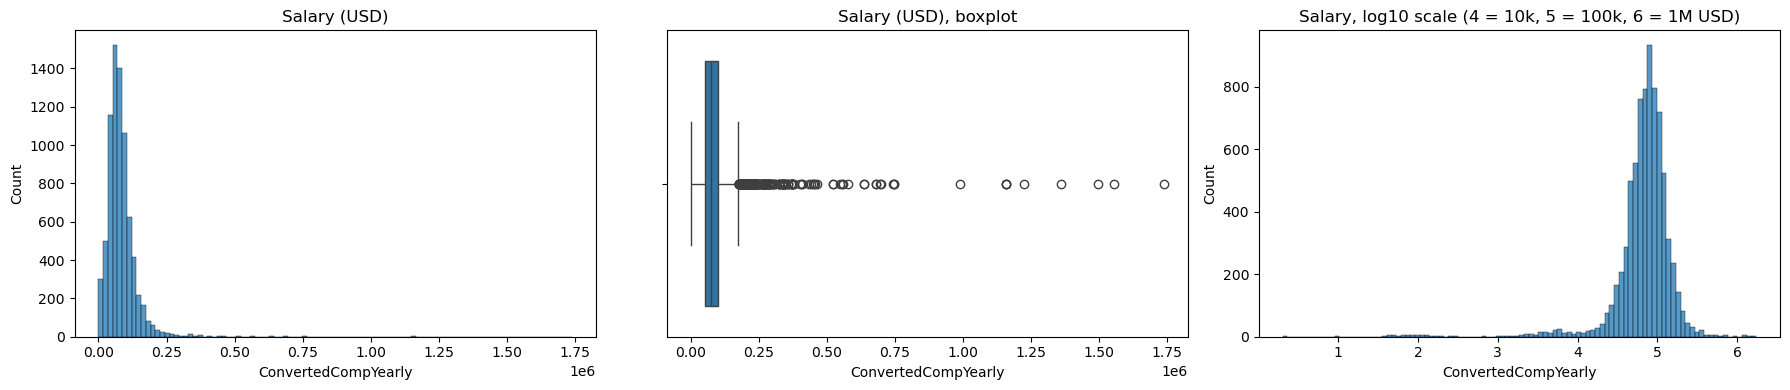

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# 1. Raw salary
sns.histplot(df_clean[target], bins=100, ax=axes[0])
axes[0].set_title("Salary (USD)")

# 2. Boxplot of the raw salary
sns.boxplot(x=df_clean[target], ax=axes[1])
axes[1].set_title("Salary (USD), boxplot")

# 3. Salary on a log10 scale
sns.histplot(np.log10(df_clean[target]), bins=100, ax=axes[2])
axes[2].set_title("Salary, log10 scale (4 = 10k, 5 = 100k, 6 = 1M USD)")

plt.tight_layout()
plt.show()

Notes:
- The scope filters already removed the worst values: the maximum went from 50 million to 1.74 million USD, while the median hardly changed.
- Low end: the 1% percentile is 2,284 USD and the 5% percentile 23,203 USD, a tenfold jump. An annual salary under about 2,000 USD isn't realistic, so the errors are in the bottom 1 to 2%.
- High end: from the 99% percentile (279,271) to the maximum (1.74 million) is a sixfold jump. Values up to the 99% percentile are possible for senior roles in Switzerland or the UK.
- The raw histogram hides the low errors. On the log scale the distribution is almost symmetric, with a separate small group around 30 to 300 USD. That gap suggests input errors rather than real salaries.

### 11.3 IQR rule

Limits: Q1 − 1.5 × IQR and Q3 + 1.5 × IQR. Since salaries are skewed, I try the rule on both the raw and the log salary.

In [31]:
def iqr_limits(series):
    """Return the lower and upper IQR limits of a numeric series."""
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

salary = df_clean[target]

# 1. IQR on the raw salary
low_raw, high_raw = iqr_limits(salary)
print("Raw salary")
print(f"  Limits: {low_raw:,.0f} to {high_raw:,.0f} USD")
print("  Below lower limit:", (salary < low_raw).sum())
print("  Above upper limit:", (salary > high_raw).sum())

# 2. IQR on the log10 salary, limits converted back to USD
log_salary = np.log10(salary)
low_log, high_log = iqr_limits(log_salary)
print("\nLog10 salary")
print(f"  Limits: {10 ** low_log:,.0f} to {10 ** high_log:,.0f} USD")
print("  Below lower limit:", (log_salary < low_log).sum())
print("  Above upper limit:", (log_salary > high_log).sum())

Raw salary
  Limits: -22,642 to 176,954 USD
  Below lower limit: 0
  Above upper limit: 308

Log10 salary
  Limits: 19,087 to 279,277 USD
  Below lower limit: 317
  Above upper limit: 77


The log version flags 394 rows. Here I check which salary ranges and countries they are.

In [32]:
# Low side: salaries below the log-IQR lower limit, grouped into ranges
low_flagged = salary[log_salary < low_log]
print("Below the lower limit, by range:")
print(pd.cut(low_flagged, bins=[0, 1_000, 10_000, 10 ** low_log]).value_counts().sort_index(), "\n")

# High side: salaries above the log-IQR upper limit, grouped into ranges
high_flagged = salary[log_salary > high_log]
print("Above the upper limit, by range:")
print(pd.cut(high_flagged, bins=[10 ** high_log, 500_000, 1_000_000, salary.max()]).value_counts().sort_index())

Below the lower limit, by range:
ConvertedCompYearly
(0.0, 1000.0]           60
(1000.0, 10000.0]      169
(10000.0, 19087.32]     88
Name: count, dtype: int64 

Above the upper limit, by range:
ConvertedCompYearly
(279276.923, 500000.0]    53
(500000.0, 1000000.0]     16
(1000000.0, 1740220.0]     8
Name: count, dtype: int64


In [33]:
# Which countries are in the uncertain zones?
uncertain_low = df_clean[(salary >= 10_000) & (log_salary < low_log)]
uncertain_high = df_clean[(log_salary > high_log) & (salary <= 500_000)]

print("10,000 USD to the lower limit, by country:")
print(uncertain_low["Country"].value_counts().head(8).to_string(), "\n")

print("Upper limit to 500,000 USD, by country:")
print(uncertain_high["Country"].value_counts().head(8).to_string())

10,000 USD to the lower limit, by country:
Country
Germany           16
Greece            10
Poland             9
Spain              7
Italy              6
Romania            5
France             4
Czech Republic     4 

Upper limit to 500,000 USD, by country:
Country
United Kingdom of Great Britain and Northern Ireland    17
Switzerland                                             15
Germany                                                  7
Ireland                                                  4
France                                                   3
Spain                                                    2
Portugal                                                 2
Netherlands                                              2


Notes:
- Raw salary: the lower limit is negative (−22,642 USD), so no low errors are caught, while the upper limit (176,954 USD) would remove realistic senior salaries. The rule doesn't fit skewed data.
- Log salary: limits of 19,087 and 279,277 USD make more sense, but they cut through realistic values:
  - below 1,000 USD: 60 rows, clear errors
  - 1,000 to 10,000 USD: 169 rows, likely errors (see 11.4)
  - 10,000 to 19,087 USD: 88 rows, could be real junior salaries in Greece, Poland, Romania etc.
  - 279,277 to 500,000 USD: 53 rows, mostly UK and Switzerland, could be real senior salaries
  - 500,000 to 1 million USD: 16 rows, doubtful
  - above 1 million USD: 8 rows, clear errors
- So IQR shows where to look, but where to cut needs common sense.

### 11.4 The extreme rows

Looking at the actual rows (country, experience, role, age) helps to see whether a value is an error.

In [34]:
context_cols = [target, "Country", "WorkExp", "DevType", "Age"]

print("15 lowest salaries")
print(df_clean.nsmallest(15, target)[context_cols].to_string())

15 lowest salaries
       ConvertedCompYearly   Country  WorkExp                                      DevType              Age
45146                  2.0   Germany     11.0                        Developer, full-stack  45-54 years old
34142                 10.0   Germany      3.0            Developer, AI apps or physical AI  35-44 years old
32804                 37.0     Italy      1.0                          Developer, back-end  18-24 years old
15199                 41.0  Bulgaria     15.0                            Developer, mobile  35-44 years old
33504                 41.0    Norway      8.0                        Developer, full-stack  35-44 years old
10512                 42.0     Spain     13.0  Developer, embedded applications or devices  35-44 years old
22375                 42.0  Bulgaria     15.0                            Developer, mobile  35-44 years old
42563                 46.0    Poland     20.0                        Developer, full-stack  45-54 years old
44667    

The lowest values come from experienced developers who report 2 to 53 USD a year. Three people from France report exactly 52 USD, which is about 45 EUR. My guess is that they entered their salary in thousands. I check this with the original answers (`CompTotal`, `Currency`). These columns can't be used in the model, but they're fine for checking.

In [35]:
# Original answers of the 15 lowest salaries
lowest_ids = df_clean.nsmallest(15, target)["ResponseId"]

df_scope[df_scope["ResponseId"].isin(lowest_ids)][["CompTotal", "Currency", target, "Country"]].sort_values(target)

,CompTotal,Currency,ConvertedCompYearly,Country
45146,2.0,EUR European Euro,2.0,Germany
34142,10.0,USD United States dollar,10.0,Germany
32804,32.0,EUR European Euro,37.0,Italy
15199,69.0,BGN\tBulgarian lev,41.0,Bulgaria
33504,410.0,NOK\tNorwegian krone,41.0,Norway
10512,36.0,EUR European Euro,42.0,Spain
22375,70.0,BGN\tBulgarian lev,42.0,Bulgaria
42563,40.0,EUR European Euro,46.0,Poland
44667,40.0,EUR European Euro,46.0,Italy
16411,42.0,EUR European Euro,49.0,Italy


In [36]:
# A random sample from the 1,000–10,000 USD range: what did these respondents type?
mid_range = df_clean[(df_clean[target] >= 1_000) & (df_clean[target] < 10_000)]

df_scope[df_scope["ResponseId"].isin(mid_range["ResponseId"])][["CompTotal", "Currency", target, "Country"]].sample(12, random_state=1)

,CompTotal,Currency,ConvertedCompYearly,Country
13554,3000.0,EUR European Euro,3480.0,Portugal
24049,3300.0,BGN\tBulgarian lev,1957.0,Bulgaria
4845,20000.0,PLN Polish zloty,5458.0,Poland
10172,5000.0,PLN Polish zloty,1364.0,Poland
35885,1300000.0,HUF\tHungarian forint,3759.0,Hungary
24300,3792.0,BGN\tBulgarian lev,2249.0,Bulgaria
27471,4200.0,EUR European Euro,4873.0,Netherlands
4380,2770.0,EUR European Euro,3214.0,Croatia
25903,1975.0,EUR European Euro,2291.0,Lithuania
34064,57000.0,SEK\tSwedish krona,5975.0,Sweden


Notes:
- Below about 1,000 USD the guess is right: people typed 45 (EUR) or 69 (BGN), meaning thousands.
- Between 1,000 and 10,000 USD, people typed monthly salaries, e.g. 4,200 EUR (Netherlands) or 20,000 PLN (Poland).
- I remove these rows instead of correcting them. For a single row I can't tell whether ×1,000 or ×12 is right (some countries pay 13 or 14 salaries a year), and a wrong correction is worse than a missing row.
- Side note: the `Currency` labels are inconsistent, some contain a tab (e.g. "BGN\tBulgarian lev"). The column isn't used in the model.

In [37]:
print("15 highest salaries")
print(df_clean.nlargest(15, target)[context_cols].to_string())

15 highest salaries
       ConvertedCompYearly                                               Country  WorkExp                                      DevType              Age
38007            1740220.0                                               Finland     20.0             Architect, software or solutions  35-44 years old
31876            1555205.0                                               Denmark      9.0                               AI/ML engineer  35-44 years old
11938            1497556.0  United Kingdom of Great Britain and Northern Ireland      9.0             Founder, technology or otherwise  25-34 years old
42326            1361415.0  United Kingdom of Great Britain and Northern Ireland     15.0                          Engineering manager  35-44 years old
48839            1225273.0  United Kingdom of Great Britain and Northern Ireland     26.0                        Developer, full-stack  45-54 years old
4583             1160147.0                                          

In [38]:
# Original answers of the 15 highest salaries
highest_ids = df_clean.nlargest(15, target)["ResponseId"]

df_scope[df_scope["ResponseId"].isin(highest_ids)][["CompTotal", "Currency", target, "Country"]].sort_values(target, ascending=False)

,CompTotal,Currency,ConvertedCompYearly,Country
38007,1500000.0,EUR European Euro,1740220.0,Finland
31876,10000000.0,DKK\tDanish krone,1555205.0,Denmark
11938,1100000.0,GBP Pound sterling,1497556.0,United Kingdom of Great Britain and Northern Ireland
42326,1000000.0,GBP Pound sterling,1361415.0,United Kingdom of Great Britain and Northern Ireland
48839,900000.0,GBP Pound sterling,1225273.0,United Kingdom of Great Britain and Northern Ireland
4583,1000000.0,EUR European Euro,1160147.0,Latvia
19059,1000000.0,EUR European Euro,1160147.0,Germany
32037,1000000.0,EUR European Euro,1160147.0,Netherlands
45681,10000000.0,NOK\tNorwegian krone,988273.0,Norway
726,16000000.0,CZK\tCzech koruna,748890.0,Czech Republic


At the top, 1,160,147 USD appears three times, which is 1,000,000 EUR. That isn't realistic, for example for a security specialist aged 18 to 24 with 4 years of experience. The original answers show round millions (1,000,000 EUR and GBP) and extra zeros (16,000,000 CZK, 4,500,000 DKK, 10,000,000 NOK, which would be normal salaries with one zero less). Same as on the low side: remove, don't correct.

### 11.5 Decision

I remove salaries below 10,000 USD and above 500,000 USD.
- 10,000 USD: monthly salaries in Europe are almost always below this, and a full-time developer salary below it is unlikely even in the lowest-paid EU countries. The log-IQR limit (19,087) would also remove real junior salaries.
- 500,000 USD: the values above it show clear error patterns. The log-IQR limit (279,277) would also remove real senior salaries in the UK and Switzerland.

In [39]:
lower_limit = 10_000
upper_limit = 500_000

too_low = df_clean[target] < lower_limit
too_high = df_clean[target] > upper_limit

# Check before removing anything (expected: 229 and 24)
print("Below lower limit:", too_low.sum())
print("Above upper limit:", too_high.sum())
print("Rows to remove:   ", (too_low | too_high).sum())

Below lower limit: 229
Above upper limit: 24
Rows to remove:    253


In [40]:
def target_summary(salary):
    """Key statistics of the target, including skewness on the raw and log10 scale."""
    return pd.Series({
        "rows": len(salary),
        "min": salary.min(),
        "median": salary.median(),
        "mean": salary.mean(),
        "max": salary.max(),
        "std": salary.std(),
        "skew_raw": salary.skew(),
        "skew_log10": np.log10(salary).skew(),
    })

before = target_summary(df_clean[target])

df_clean = df_clean[~(too_low | too_high)].copy()

after = target_summary(df_clean[target])

pd.DataFrame({"before": before, "after": after}).round(2)

,before,after
rows,7685.00,7432.00
min,2.00,10031.00
median,75410.00,75410.00
mean,84678.07,84564.70
max,1740220.00,464059.00
std,68703.14,46342.88
skew_raw,9.14,2.19
skew_log10,-3.90,-0.27


Notes:
- 253 rows removed (3.3%), 7,432 left.
- The median stays the same and the mean barely changes, so only the tails were affected.
- The skewness of the raw salary drops from 9.1 to 2.2. On the log scale it goes from −3.9 to −0.3: the low errors were pulling it to the left. Now it's close to symmetric, so a log target is worth testing.

## 12. Cleaning step 3: experience columns

`WorkExp` is the number of years of professional work (any job, not only coding). `YearsCode` is the number of years of coding, including school and university. I check the distribution, impossible values, whether the two columns match, and the blank `WorkExp` values.

### 12.1 Distribution

In [41]:
print(df_clean[["WorkExp", "YearsCode"]].describe(percentiles=[0.01, 0.5, 0.99]).round(1))

print("\nWorkExp = 0:  ", (df_clean["WorkExp"] == 0).sum())
print("YearsCode = 0:", (df_clean["YearsCode"] == 0).sum())

       WorkExp  YearsCode
count   7391.0     7413.0
mean      12.8       18.2
std        8.8        9.9
min        1.0        1.0
1%         1.0        4.0
50%       11.0       16.0
99%       39.0       45.0
max      100.0      100.0

WorkExp = 0:   0
YearsCode = 0: 0


### 12.2 Impossible values

`Age` is a range, so I use its upper bound. A value is impossible if the person would have started working before 14 or coding before 5. "65 years or older" and "Prefer not to say" aren't checked.

In [42]:
age_upper = {
    "18-24 years old": 24,
    "25-34 years old": 34,
    "35-44 years old": 44,
    "45-54 years old": 54,
    "55-64 years old": 64,
}
max_age = df_clean["Age"].map(age_upper)

impossible_work = df_clean["WorkExp"] > max_age - 14
impossible_code = df_clean["YearsCode"] > max_age - 5

print("Impossible WorkExp:  ", impossible_work.sum())
print("Impossible YearsCode:", impossible_code.sum())

df_clean[impossible_work | impossible_code][[target, "WorkExp", "YearsCode", "Age", "DevType", "Country"]]

Impossible WorkExp:   2
Impossible YearsCode: 3


,ConvertedCompYearly,WorkExp,YearsCode,Age,DevType,Country
12881,63986.0,23.0,40.0,35-44 years old,"Developer, back-end",United Kingdom of Great Britain and Northern Ireland
16715,336327.0,100.0,100.0,18-24 years old,System administrator,Germany
37119,44086.0,3.0,100.0,25-34 years old,Data engineer,Italy
39885,210788.0,12.0,14.0,18-24 years old,DevOps engineer or professional,Switzerland


### 12.3 Do the two columns match?

Normally `YearsCode` is at least as high as `WorkExp`, because it includes education. But someone who changed careers can have more years of work than of coding.

In [43]:
code_less_than_work = df_clean["YearsCode"] < df_clean["WorkExp"]
difference = (df_clean["WorkExp"] - df_clean["YearsCode"])[code_less_than_work]

print("YearsCode < WorkExp:", code_less_than_work.sum(),
      f"({code_less_than_work.mean() * 100:.1f}%)")
print("\nDifference in years (WorkExp − YearsCode):")
print(difference.describe().round(1))

YearsCode < WorkExp: 248 (3.3%)

Difference in years (WorkExp − YearsCode):
count    248.0
mean       6.0
std        5.0
min        1.0
25%        2.0
50%        5.0
75%        9.0
max       28.0
dtype: float64


### 12.4 Blank `WorkExp`

The survey said to leave `WorkExp` blank if the answer is 0. If people did that, the blank rows should look like beginners.

In [44]:
blank_work = df_clean["WorkExp"].isnull()
print("Blank WorkExp:", blank_work.sum(), "\n")

print("Age of respondents with blank WorkExp:")
print(df_clean.loc[blank_work, "Age"].value_counts().to_string(), "\n")

# Median salary by experience, with blanks shown as 0
experience_filled = df_clean["WorkExp"].fillna(0)
df_clean[experience_filled <= 3].groupby(experience_filled)[target].agg(["count", "median"])

Blank WorkExp: 41 

Age of respondents with blank WorkExp:
Age
18-24 years old    19
25-34 years old    18
35-44 years old     4 



,count,median
WorkExp,,
0.0,41,39213.0
1.0,182,41249.5
2.0,280,48726.0
3.0,409,50314.0


Notes:
- The medians are realistic (11 years of work, 16 years of coding).
- Both columns have a maximum of 100 years.
- There is no 0 anywhere, although there must be people with less than a year of experience. That fits the "leave blank if 0" instruction.
- 4 rows are impossible (e.g. 100 years at age 18 to 24, or coding since age 4). Two of them also have unusually high salaries.
- 248 rows (3.3%) have more years of work than of coding (median difference 5 years). That looks like career changers, not errors.
- The 41 people with a blank `WorkExp` are young (90% under 35) and earn a bit less than people with 1 year of experience (median 39,213 vs 41,250 USD). So blank really means 0.

### 12.5 Decision

- Remove the 4 impossible rows. If one answer is impossible, I don't trust the rest of that row either.
- Keep the 248 career changers. Removing them would bias the model against people who switch careers.
- Fill the blank `WorkExp` values with 0. This follows the survey instruction, so it isn't really imputation.
- Leave the 19 missing `YearsCode` values for now. I'll fill them in the modelling notebook after the train-test split, so the test data doesn't influence the fill value.

In [45]:
rows_before = len(df_clean)

# 1. Remove rows with impossible experience values
df_clean = df_clean[~(impossible_work | impossible_code)].copy()

# 2. Blank WorkExp means 0 years (survey instruction)
blank_count = df_clean["WorkExp"].isnull().sum()
df_clean["WorkExp"] = df_clean["WorkExp"].fillna(0)

print("Rows before:", rows_before)
print("Rows after: ", len(df_clean))
print("Removed:    ", rows_before - len(df_clean))
print("\nBlank WorkExp filled with 0:", blank_count)
print("Missing values left:", df_clean[["WorkExp", "YearsCode"]].isnull().sum().to_dict())
print("New maximum:", df_clean[["WorkExp", "YearsCode"]].max().to_dict())

Rows before: 7432
Rows after:  7428
Removed:     4

Blank WorkExp filled with 0: 41
Missing values left: {'WorkExp': 0, 'YearsCode': 19}
New maximum: {'WorkExp': 50.0, 'YearsCode': 60.0}


Notes:
- 4 rows removed, 7,428 left.
- No missing `WorkExp` values left. `YearsCode` still has 19.
- The new maximums (50 years of work, 60 of coding) are realistic for people over 55.

## 13. Cleaning step 4: categorical columns

Three kinds of changes:
- shorten long labels so they are readable in charts,
- group rare categories with similar ones,
- set answers that don't fit an ordered scale ("Other", "I don't know", "Prefer not to say") to missing. They will be imputed in the modelling notebook, after the train-test split.

I group categories by meaning, not by salary. Grouping by salary would put information from the target into the features.

In [ ]:
def apply_mapping(series, mapping):
    """Map old labels to new ones and report labels that are missing from the mapping."""
    unmapped = set(series.dropna().unique()) - set(mapping)
    if unmapped:
        print(f"{series.name}: not in mapping -> {unmapped}")
    return series.map(mapping)

Labels that are not in a mapping would silently become missing, so the function prints them. An empty output means every label was mapped.

### 13.1 Job role (`DevType`)

The large developer roles stay as they are. The small roles are grouped into job families, which gives 12 groups.

In [ ]:
devtype_map = {
    "Developer, full-stack": "Full-stack developer",
    "Developer, back-end": "Back-end developer",
    "Architect, software or solutions": "Architect",
    "Developer, desktop or enterprise applications": "Desktop/enterprise developer",
    "Developer, front-end": "Front-end developer",
    "Developer, embedded applications or devices": "Embedded developer",
    "Developer, mobile": "Mobile developer",
    "Developer, game or graphics": "Other developer",
    "Developer, QA or test": "Other developer",
    "Data engineer": "Data & AI",
    "AI/ML engineer": "Data & AI",
    "Data scientist": "Data & AI",
    "Applied scientist": "Data & AI",
    "Developer, AI apps or physical AI": "Data & AI",
    "Data or business analyst": "Data & AI",
    "Financial analyst or engineer": "Data & AI",
    "DevOps engineer or professional": "DevOps & infrastructure",
    "Cloud infrastructure engineer": "DevOps & infrastructure",
    "Cybersecurity or InfoSec professional": "DevOps & infrastructure",
    "Database administrator or engineer": "DevOps & infrastructure",
    "System administrator": "DevOps & infrastructure",
    "Support engineer or analyst": "DevOps & infrastructure",
    "Engineering manager": "Management",
    "Senior executive (C-suite, VP, etc.)": "Management",
    "Project manager": "Management",
    "Product manager": "Management",
    "Founder, technology or otherwise": "Management",
    "Other (please specify):": "Other",
    "Academic researcher": "Other",
    "UX, Research Ops or UI design professional": "Other",
}

df_clean["DevType"] = apply_mapping(df_clean["DevType"], devtype_map)
df_clean["DevType"].value_counts()

### 13.2 Country

The 8 countries with fewer than 50 respondents are grouped by region.

In [ ]:
small_countries = {
    "Lithuania": "Other Central & Eastern Europe",
    "Estonia": "Other Central & Eastern Europe",
    "Latvia": "Other Central & Eastern Europe",
    "Slovenia": "Other Central & Eastern Europe",
    "Luxembourg": "Other Western & Southern Europe",
    "Iceland": "Other Western & Southern Europe",
    "Cyprus": "Other Western & Southern Europe",
    "Malta": "Other Western & Southern Europe",
}

# replace() only changes the listed countries and keeps all others as they are
df_clean["Country"] = df_clean["Country"].replace(small_countries)

# The long UK name is shortened for charts
df_clean["Country"] = df_clean["Country"].replace(
    {"United Kingdom of Great Britain and Northern Ireland": "United Kingdom"})

print("Countries / groups:", df_clean["Country"].nunique())
df_clean["Country"].value_counts().tail(5)

### 13.3 Ordered columns (`EdLevel`, `OrgSize`, `Age`)

Short labels, and answers without a place in the order become missing. Primary school (19 people) is merged into "Secondary or lower", and 65+ (23 people) into "55+". The labels contain curly apostrophes (`’`), so they are copied from the data.

In [ ]:
edlevel_map = {
    "Primary/elementary school": "Secondary or lower",
    "Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)": "Secondary or lower",
    "Some college/university study without earning a degree": "Some college",
    "Associate degree (A.A., A.S., etc.)": "Associate",
    "Bachelor’s degree (B.A., B.S., B.Eng., etc.)": "Bachelor",
    "Master’s degree (M.A., M.S., M.Eng., MBA, etc.)": "Master",
    "Professional degree (JD, MD, Ph.D, Ed.D, etc.)": "Doctorate/professional",
    "Other (please specify):": np.nan,
}

orgsize_map = {
    "Less than 20 employees": "<20",
    "20 to 99 employees": "20-99",
    "100 to 499 employees": "100-499",
    "500 to 999 employees": "500-999",
    "1,000 to 4,999 employees": "1,000-4,999",
    "5,000 to 9,999 employees": "5,000-9,999",
    "10,000 or more employees": "10,000+",
    "I don’t know": np.nan,
}

age_map = {
    "18-24 years old": "18-24",
    "25-34 years old": "25-34",
    "35-44 years old": "35-44",
    "45-54 years old": "45-54",
    "55-64 years old": "55+",
    "65 years or older": "55+",
    "Prefer not to say": np.nan,
}

df_clean["EdLevel"] = apply_mapping(df_clean["EdLevel"], edlevel_map)
df_clean["OrgSize"] = apply_mapping(df_clean["OrgSize"], orgsize_map)
df_clean["Age"] = apply_mapping(df_clean["Age"], age_map)

# The natural order of each column, used later in EDA and encoding
edlevel_order = ["Secondary or lower", "Some college", "Associate", "Bachelor", "Master", "Doctorate/professional"]
orgsize_order = ["<20", "20-99", "100-499", "500-999", "1,000-4,999", "5,000-9,999", "10,000+"]
age_order = ["18-24", "25-34", "35-44", "45-54", "55+"]

for col, order in [("EdLevel", edlevel_order), ("OrgSize", orgsize_order), ("Age", age_order)]:
    print(df_clean[col].value_counts(dropna=False).reindex(order + [np.nan]).to_string(), "\n")

### 13.4 Other columns (`RemoteWork`, `Industry`, `ICorPM`)

Only shorter labels. No grouping is needed: the smallest category has more than 100 people.

In [ ]:
remote_map = {
    "Remote": "Remote",
    "In-person": "In-person",
    "Hybrid (some in-person, leans heavy to flexibility)": "Hybrid (mostly flexible)",
    "Hybrid (some remote, leans heavy to in-person)": "Hybrid (mostly in-person)",
    "Your choice (very flexible, you can come in when you want or just as needed)": "Own choice",
}

industry_map = {
    "Software Development": "Software development",
    "Other:": "Other",
    "Internet, Telecomm or Information Services": "Internet & telecom",
    "Fintech": "Fintech",
    "Manufacturing": "Manufacturing",
    "Banking/Financial Services": "Banking & finance",
    "Healthcare": "Healthcare",
    "Retail and Consumer Services": "Retail & consumer",
    "Transportation, or Supply Chain": "Transport & supply chain",
    "Energy": "Energy",
    "Media & Advertising Services": "Media & advertising",
    "Government": "Government",
    "Computer Systems Design and Services": "IT services",
    "Higher Education": "Higher education",
    "Insurance": "Insurance",
}

icorpm_map = {
    "Individual contributor": "Individual contributor",
    "People manager": "Manager",
}

df_clean["RemoteWork"] = apply_mapping(df_clean["RemoteWork"], remote_map)
df_clean["Industry"] = apply_mapping(df_clean["Industry"], industry_map)
df_clean["ICorPM"] = apply_mapping(df_clean["ICorPM"], icorpm_map)

for col in ["RemoteWork", "Industry", "ICorPM"]:
    print(df_clean[col].value_counts(dropna=False).to_string(), "\n")

### 13.5 Check

In [ ]:
categorical_cols = ["DevType", "Country", "EdLevel", "OrgSize", "RemoteWork", "Industry", "ICorPM", "Age"]

pd.DataFrame({
    "categories": df_clean[categorical_cols].nunique(),
    "smallest_group": [df_clean[col].value_counts().min() for col in categorical_cols],
    "missing": df_clean[categorical_cols].isnull().sum(),
})

Notes:
- All labels were mapped (no "not in mapping" messages).
- `DevType` went from 30 to 12 groups, the smallest is "Other developer" with 121 people.
- `Country` went from 31 to 25 categories. The smallest is the "Other Western & Southern Europe" group (44 people); I keep it rather than drop these countries.
- The ordered columns now have short labels and a defined order (`edlevel_order`, `orgsize_order`, `age_order`).
- Missing values that will be imputed after the train-test split: `ICorPM` 98, `EdLevel` 71, `OrgSize` 66, `RemoteWork` 19, `Industry` 9, `Age` 3 (plus `YearsCode` 19 from section 12). Each is below 1.5% of the rows.

## 14. Programming languages

`LanguageHaveWorkedWith` holds several answers in one cell (e.g. `Python;SQL;JavaScript`). I split it into one 0/1 column per language with `str.get_dummies(sep=";")`. Unlike one-hot encoding, a row can have several 1s.

What I do here and what I leave for the modelling notebook:
- Here: the split, the number of languages per person (`n_languages`) and a flag for people without language data (`languages_missing`). These don't learn anything from the data, each row is handled on its own.
- Later: choosing which languages go into the model. That decision is based on how common each language is, so it should only use the training data.

The 419 people without language data were probably not shown the language list after a screening question. Their language columns become 0, the flag tells the model that the information is missing, and `n_languages` stays empty so it can be imputed later.

In [ ]:
languages = df_clean["LanguageHaveWorkedWith"]

# One 0/1 column per language (empty cells give 0 in every column)
lang_dummies = languages.str.get_dummies(sep=";")
lang_dummies = lang_dummies.rename(columns={
    "Bash/Shell (all shells)": "Bash/Shell",
    "Visual Basic (.Net)": "Visual Basic",
})
lang_dummies = lang_dummies.add_prefix("lang_")

print("Languages:", lang_dummies.shape[1])

# Share of respondents using each language
(lang_dummies.mean() * 100).round(1).sort_values(ascending=False).head(20)

In [ ]:
df_clean["languages_missing"] = languages.isnull().astype(int)

# Number of languages; empty where the answer is missing (0 would be wrong)
df_clean["n_languages"] = lang_dummies.sum(axis=1).where(languages.notnull())

df_clean = pd.concat([df_clean.drop(columns="LanguageHaveWorkedWith"), lang_dummies], axis=1)

print("Missing language data:", df_clean["languages_missing"].sum())
print(df_clean["n_languages"].describe().round(1))
print("\nShape:", df_clean.shape)

Notes:
- 42 languages. The most common are JavaScript (61%), HTML/CSS (57%), SQL (57%) and Python (51%). 24 languages are used by less than 5% of the respondents.
- People use 6 languages on median, with a maximum of 26.
- 419 people (5.6%) have no language data. Their roles look like the rest of the data, so they are not a special group.

## 15. Save the cleaned data

Summary of all cleaning steps:

| Step | Rows |
|---|---|
| Raw data | 49,191 |
| Scope filters (salary given, professional developer, employed, Europe) | 7,709 |
| Duplicates removed | 7,706 |
| Answers that contradict the scope removed | 7,685 |
| Salary outliers removed (below 10,000 or above 500,000 USD) | 7,432 |
| Impossible experience values removed | 7,428 |

The cleaned file is used by the EDA and modelling notebooks. It is small enough to be stored on GitHub.

In [ ]:
# Final check before saving
print(df_clean.shape)
print("Duplicate IDs:", df_clean["ResponseId"].duplicated().sum())
print("Missing values left:")
print(df_clean.isnull().sum()[lambda s: s > 0].sort_values(ascending=False).to_string())

In [ ]:
output_path = "../data/processed/survey_clean_2025.csv"
df_clean.to_csv(output_path, index=False)

# Read the file back to check that it was saved correctly
check = pd.read_csv(output_path)
print("Saved:", check.shape)

The ordered columns (`EdLevel`, `OrgSize`, `Age`) are saved as text, because a CSV file doesn't store category order. The order lists from section 13.3 are defined again in the next notebooks.

## Next steps
- `02_eda_statistics.ipynb`: univariate and bivariate analysis, hypothesis tests
- `03_modeling.ipynb`: choose the languages for the model, impute the remaining missing values after the train-test split, encode, train and compare models